# Cows and buffaloes across five Indian climate scenarios
15 cows + 15 buffaloes total: 3 of each species per region. Default history: 72 hours at one-minute intervals (129,600 rows).

Regions: Jaisalmer (hot/dry), Thrissur (hot/humid), Ludhiana (warm plains), Bengaluru (mild plateau), Srinagar (cold winter). Different dates represent different seasonal scenarios, not real observed weather.

This notebook generates and explores livestock data. Train the separate six-task livestock model with `python train_livestock.py`, then use the Predictions tab in `livestock_app.py`. Assumptions and sources are in `data/livestock/README.md`.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/pet_health_ai/livestock_data.py').exists())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
from pet_health_ai.livestock_data import save_livestock_data, LIVESTOCK_TASKS
OUTPUT = ROOT / 'data/livestock'
print('Project:', ROOT)

Project: D:\Workspace_AI\Ktino_pethealth_minimalsensor\pet_health_minimal


In [2]:
# Set True to regenerate the named livestock output files with these settings.
REGENERATE = False
COWS, BUFFALOES, HOURS, SAMPLE_MINUTES, SEED = 15, 15, 72, 1, 20260922
path = OUTPUT / 'synthetic_livestock_sensor_data.csv'
if REGENERATE or not path.exists():
    df = save_livestock_data(OUTPUT, cows=COWS, buffaloes=BUFFALOES, hours=HOURS, sample_minutes=SAMPLE_MINUTES, seed=SEED)
else:
    df = pd.read_csv(path, parse_dates=['timestamp'])
print(f'{df.animal_id.nunique()} animals, {len(df):,} readings')
print(df.groupby(['region', 'species']).animal_id.nunique().unstack())

30 animals, 129,600 readings
species    buffalo  cow
region                 
Bengaluru        3    3
Jaisalmer        3    3
Ludhiana         3    3
Srinagar         3    3
Thrissur         3    3


In [3]:
assert set(df.species) == {'cow', 'buffalo'}
assert df.region.nunique() == 5
assert df.animal_id.eq(df.pet_id).all()
assert not df.duplicated(['animal_id', 'timestamp']).any()
gaps = df.groupby('animal_id').timestamp.diff().dropna()
assert gaps.nunique() == 1 and gaps.iloc[0] > pd.Timedelta(0)
targets = ['target_' + name for name in LIVESTOCK_TASKS]
assert df.label.eq(df[targets].max(axis=1)).all()
print('Sampling interval:', gaps.iloc[0])
print('Animal counts:', df.groupby('species').animal_id.nunique().to_dict())
print('Positive synthetic readings per task:')
print(df[targets].sum())

Sampling interval: 0 days 00:01:00
Animal counts: {'buffalo': 15, 'cow': 15}
Positive synthetic readings per task:
target_hypoxemia               3600
target_fever                   3600
target_abnormal_resting_hr     1800
target_activity_reduction      1800
target_heat_stress            42536
target_cold_stress            11591
dtype: int64


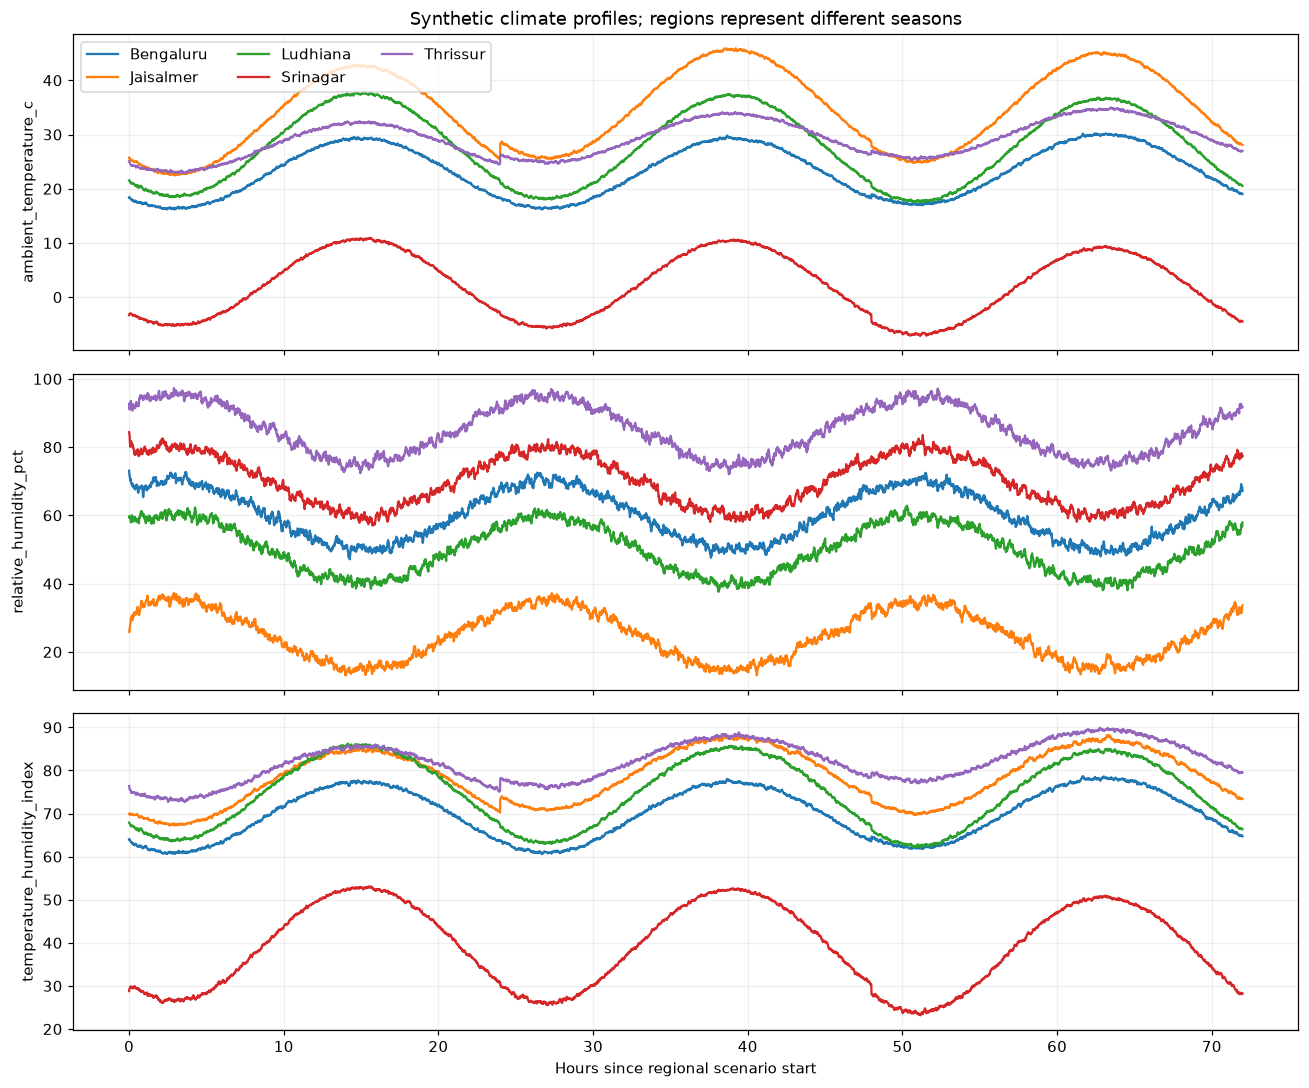

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
weather = df.drop_duplicates(['region', 'timestamp'])
for region, rows in weather.groupby('region'):
    rows = rows.sort_values('timestamp')
    elapsed = (rows.timestamp - rows.timestamp.min()).dt.total_seconds() / 3600
    for axis, column in zip(axes, ['ambient_temperature_c', 'relative_humidity_pct', 'temperature_humidity_index']):
        axis.plot(elapsed, rows[column], label=region)
        axis.set_ylabel(column)
        axis.grid(alpha=0.2)
axes[0].legend(ncol=3)
axes[0].set_title('Synthetic climate profiles; regions represent different seasons')
axes[-1].set_xlabel('Hours since regional scenario start')
fig.tight_layout()
plt.show()

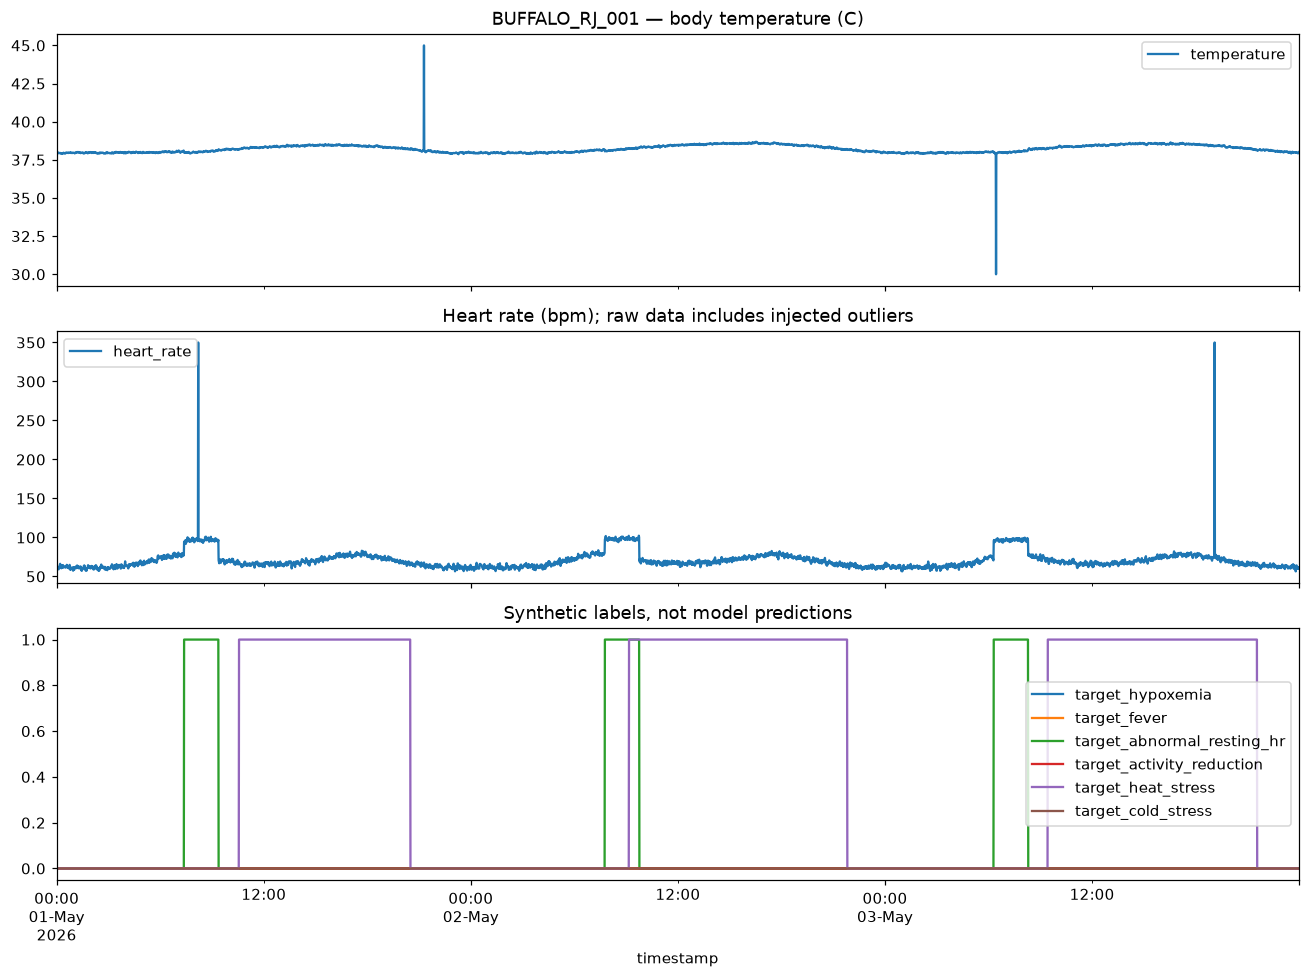

In [5]:
# Change this ID to inspect another species/region.
ANIMAL_ID = 'BUFFALO_RJ_001'
animal = df.loc[df.animal_id.eq(ANIMAL_ID)].set_index('timestamp')
if animal.empty:
    raise ValueError('Choose an ID from df.animal_id.unique()')
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
animal[['temperature']].plot(ax=axes[0], title=ANIMAL_ID + ' — body temperature (C)')
animal[['heart_rate']].plot(ax=axes[1], title='Heart rate (bpm); raw data includes injected outliers')
animal[targets].plot(ax=axes[2], title='Synthetic labels, not model predictions')
fig.tight_layout()
plt.show()

## Train and predict
Train: `.\.venv\Scripts\python.exe train_livestock.py`.

Launch: `.\.venv\Scripts\python.exe -m streamlit run livestock_app.py --server.port 8502`. Select an animal, then click **Run livestock predictions**.

The pipeline excludes targets and simulator metadata, adds species and climate features, and fits six separate XGBoost classifiers. Artifacts are in `artifacts/livestock/`; reports are in `reports/livestock/`. See `docs/livestock_model.md` for validation and experimental health-score details.

Synthetic episode charts above are known generated labels, not predictions. Test animals are held out, but regional weather is shared and heat/cold targets derive from exposure rules. Real-world accuracy requires independent real-data evaluation.

THI context: [ICAR-NDRI study](https://epubs.icar.org.in/index.php/IJAnS/article/download/119779/52018/379780). Buffalo shelter/cooling context: [ICAR study](https://epubs.icar.org.in/index.php/IJAnS/article/view/31207). Regional envelopes and response coefficients remain chosen assumptions.